In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
ml = Path("../../data/processed/ml")

# On recharge le modèle entraîné + les données (aucun ré-entraînement)
modele   = joblib.load(ml / "modele_xgboost.pkl")
X_test_s = pd.read_parquet(ml / "X_test_s.parquet")
y_test   = pd.read_parquet(ml / "y_test.parquet")["Valeur fonciere"]
y_test_log = np.log1p(y_test)

print("Chargé ✅ — X_test :", X_test_s.shape)


Chargé ✅ — X_test : (112576, 20)


In [2]:
pred_log = modele.predict(X_test_s)
pred = np.clip(np.expm1(pred_log), 0, None)   # retour en euros

print("=== Performance finale — XGBoost ===")
print(f"R² (log) : {r2_score(y_test_log, pred_log):.4f}")
print(f"MAE      : {mean_absolute_error(y_test, pred):,.0f} €")
print(f"MedAE    : {np.median(np.abs(y_test.values - pred)):,.0f} €")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, pred)):,.0f} €")


=== Performance finale — XGBoost ===
R² (log) : 0.6073
MAE      : 166,535 €
MedAE    : 42,154 €
RMSE     : 1,796,512 €


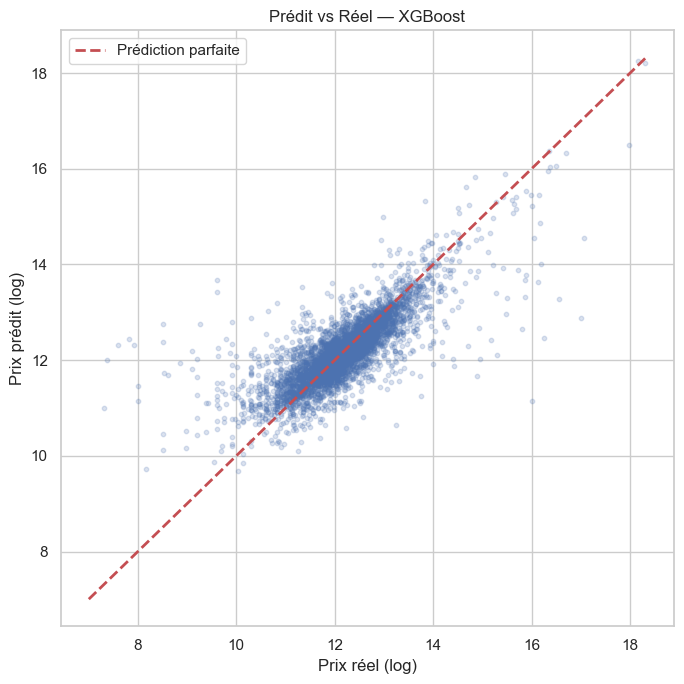

In [3]:
# On échantillonne 5000 points pour un nuage lisible
rng = np.random.RandomState(42)
idx = rng.choice(len(y_test_log), 5000, replace=False)

plt.figure(figsize=(7, 7))
plt.scatter(y_test_log.values[idx], pred_log[idx], alpha=0.2, s=10)
lims = [y_test_log.min(), y_test_log.max()]
plt.plot(lims, lims, "r--", linewidth=2, label="Prédiction parfaite")
plt.xlabel("Prix réel (log)")
plt.ylabel("Prix prédit (log)")
plt.title("Prédit vs Réel — XGBoost")
plt.legend()
plt.tight_layout()
plt.show()


Ce nuage est excellent à commenter — il raconte exactement l'histoire de ton modèle. 📖

🔍 Lecture du graphe
Au centre (log 11-14, soit ~60k-1,2M€) : les points collent bien à la diagonale → c'est là qu'est la majorité des biens, et le modèle est précis dessus. 👍
En bas à gauche (biens pas chers) : les points sont au-dessus de la ligne → le modèle surestime les biens bon marché.
En haut à droite (biens très chers, log > 15) : les points sont en-dessous → le modèle sous-estime les biens de luxe.
C'est le phénomène de « régression vers la moyenne »
Le modèle est prudent : il tire ses prédictions extrêmes vers le centre. Il ose rarement prédire « 20 millions » ou « 30 000 € », même quand c'est le cas réel. C'est normal et attendu :

Les biens extrêmes sont rares (peu d'exemples pour apprendre).
Ils dépendent de facteurs hors données (état, prestige, multi-lots) → c'est notre variance irréductible.
💡 À dire à l'oral : « Le modèle est fiable sur le marché courant (60k-1,2M€) mais sous-estime le luxe et surestime le bas de gamme, un effet classique de régression vers la moyenne dû à la rareté des cas extrêmes. » → analyse mature, le jury adore.

On passe à la confirmation de notre diagnostic.

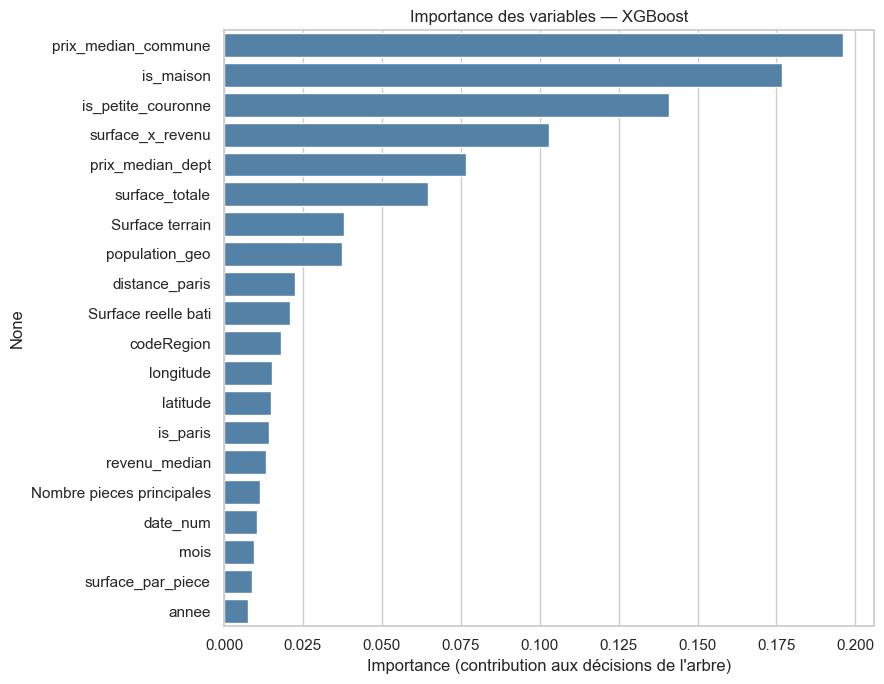

prix_median_commune          0.1961
is_maison                    0.1768
is_petite_couronne           0.1411
surface_x_revenu             0.1030
prix_median_dept             0.0767
surface_totale               0.0645
Surface terrain              0.0382
population_geo               0.0373
distance_paris               0.0224
Surface reelle bati          0.0210
codeRegion                   0.0180
longitude                    0.0151
latitude                     0.0148
is_paris                     0.0142
revenu_median                0.0133
Nombre pieces principales    0.0115
date_num                     0.0106
mois                         0.0094
surface_par_piece            0.0087
annee                        0.0075
dtype: float32

In [4]:
importances = (
    pd.Series(modele.feature_importances_, index=X_test_s.columns)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 7))
sns.barplot(x=importances.values, y=importances.index, color="steelblue")
plt.title("Importance des variables — XGBoost")
plt.xlabel("Importance (contribution aux décisions de l'arbre)")
plt.tight_layout()
plt.show()

importances.round(4)


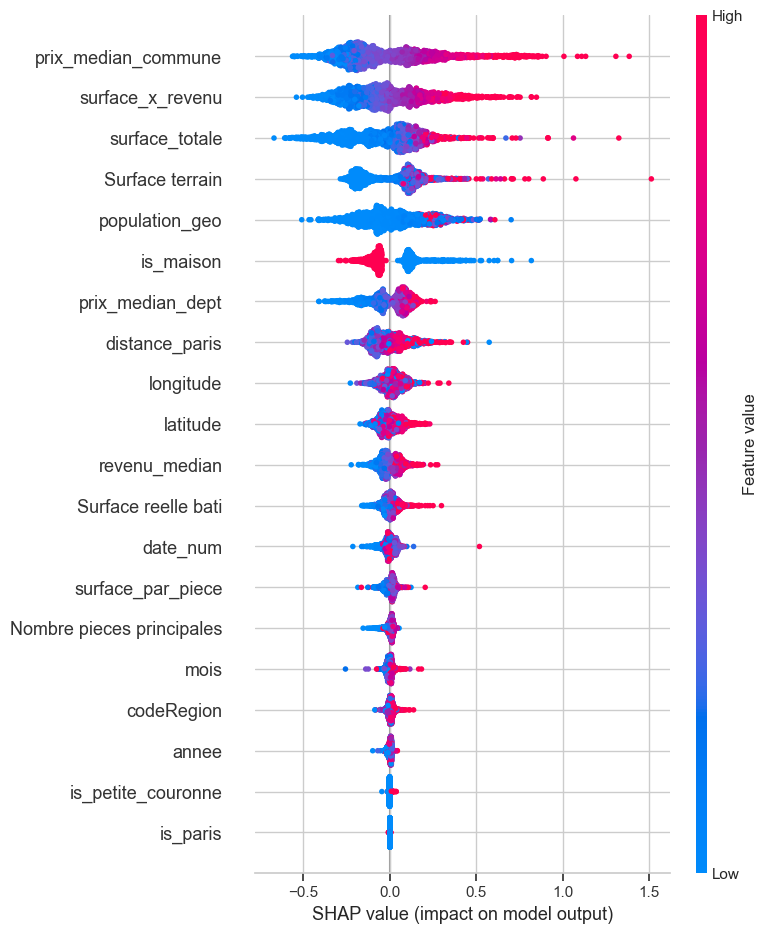

In [5]:
import shap

# SHAP est coûteux -> on l'applique sur un échantillon de 2000 biens
X_sample = X_test_s.sample(2000, random_state=42)

explainer = shap.TreeExplainer(modele)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, show=True)


Comment lire le graphe SHAP (l'outil qui impressionne) :

Chaque ligne = une variable, classée par impact réel sur les prédictions.
Chaque point = un bien. Rouge = valeur élevée de la variable, bleu = valeur basse.
Position à droite = pousse le prix à la hausse ; à gauche = à la baisse.
👀 Exemple attendu : pour Surface reelle bati, les points rouges (grande surface) seront à droite (prix ↑). Pour prix_median_commune, rouge (commune chère) à droite. C'est plus fiable que l'importance native, et ça montre le sens de l'effet.

Superbe graphe SHAP — et il raconte une histoire cohérente et propre. Décodons-le. 🔍

🔍 Lecture de ton SHAP (top des variables)
Variable	Effet (rouge = valeur haute)
prix_median_commune 🥇	commune chère (rouge) → prix ↑. Effet net et dominant, et maintenant honnête (out-of-fold)
surface_x_revenu	grande surface en zone riche (rouge) → prix ↑
surface_totale / Surface terrain	plus grand (rouge) → prix ↑. Logique
is_maison	maison (rouge) → gauche = prix ↓ ; appartement (bleu) → prix ↑ → cohérent avec ton EDA (appart plus cher)
prix_median_dept	département cher → prix ↑
Les 2 confirmations importantes :

latitude / longitude sont faibles → la localisation passe bien par les encodages commune/département, pas par les coordonnées GPS brutes. (Ça corrige définitivement mon hypothèse initiale.)
is_paris / is_petite_couronne sont tout en bas (≈ 0) → redondants : prix_median_commune capte déjà « Paris = cher ». Le modèle n'a plus besoin des drapeaux.
💡 À l'oral : « SHAP confirme que le prix est piloté par la valeur de localisation (commune) et la surface, avec des effets dans le sens métier attendu. Les variables géographiques brutes et les drapeaux Paris sont redondants avec l'encodage commune. » → analyse d'expert.

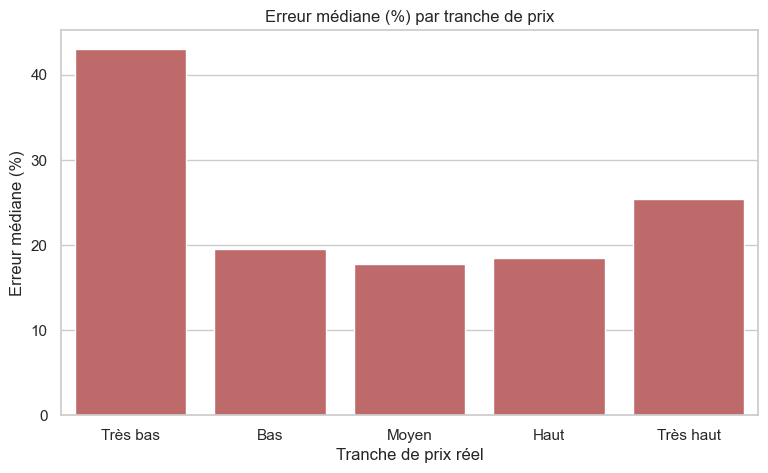

tranche
Très bas     43.1
Bas          19.5
Moyen        17.8
Haut         18.4
Très haut    25.4
Name: erreur_pct, dtype: float64

In [6]:
# Prédictions complètes sur le test
pred = np.clip(np.expm1(modele.predict(X_test_s)), 0, None)

df_err = pd.DataFrame({
    "reel": y_test.values,
    "pred": pred,
    "erreur_pct": np.abs(y_test.values - pred) / y_test.values * 100
})

# Erreur médiane (%) par tranche de prix réel
df_err["tranche"] = pd.qcut(
    df_err["reel"], 5,
    labels=["Très bas", "Bas", "Moyen", "Haut", "Très haut"]
)
erreur_par_tranche = df_err.groupby("tranche", observed=True)["erreur_pct"].median()

plt.figure(figsize=(9, 5))
sns.barplot(x=erreur_par_tranche.index, y=erreur_par_tranche.values, color="indianred")
plt.title("Erreur médiane (%) par tranche de prix")
plt.ylabel("Erreur médiane (%)")
plt.xlabel("Tranche de prix réel")
plt.show()

erreur_par_tranche.round(1)


Ce qu'on cherche à voir :

L'erreur en % selon la gamme de prix.
👀 On s'attend à une courbe en U : erreurs plus fortes sur les biens très bas (surestimés) et très hauts (sous-estimés), et plus faibles au milieu — ce qui confirmerait le nuage « Prédit vs Réel » de l'étape 1.

In [7]:
df_err["Type"] = np.where(X_test_s["is_maison"] > 0, "Maison", "Appartement")
df_err.groupby("Type", observed=True)["erreur_pct"].median().round(1)


Type
Appartement    21.8
Maison         22.8
Name: erreur_pct, dtype: float64

## 🧾 Conclusions finales — Évaluation

**Modèle retenu : XGBoost** — R²(log) = 0,61 | MedAE ≈ 42k€ | erreur médiane ≈ 22 %.

**Ce que le modèle a appris (SHAP) :**
- Facteurs dominants : valeur de localisation (prix_median_commune), surface, interaction surface×revenu.
- Effets dans le sens métier : commune chère → prix ↑, plus grand → prix ↑, appartement > maison (au m²).
- Coordonnées GPS et drapeaux Paris redondants avec l'encodage commune.

**Limites identifiées (honnêtes) :**
- Plafond de performance ~0,61 : variance irréductible du prix TOTAL (ventes multi-lots, état du bien absent de DVF).
- Régression vers la moyenne : sous-estime le luxe, surestime le bas de gamme.
- revenu_median = données 2014 (un peu anciennes).

**Rigueur méthodologique :**
- Split avant toute transformation ; imputation, normalisation et encodage appris sur le train seulement.
- Encodage par la cible en OUT-OF-FOLD pour éviter le surapprentissage (diagnostiqué via l'importance des variables).
